## 1. Install Dependencies and Import Libraries

Install necessary libraries including PyTorch, NumPy, Matplotlib, and scikit-learn for data preprocessing and visualization.

In [1]:
!pip install -q torch torchvision numpy matplotlib scikit-learn

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import warnings
warnings.filterwarnings('ignore')

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.11.0+cpu


## 2. Load and Prepare Dataset

Load the MNIST dataset, normalize the data to the range [0, 1], flatten the images, and create DataLoaders for training and testing.

In [3]:
# Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),  # Converts to [0, 1] range automatically
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create DataLoaders
batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Get a sample to check dimensions
sample_image, _ = next(iter(train_loader))
print(f"Training set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")
print(f"Image shape: {sample_image.shape}")
print(f"Image value range: [{sample_image.min():.3f}, {sample_image.max():.3f}]")

# Flatten all data for reconstruction
x_train_flat = sample_image.view(sample_image.size(0), -1).cpu().numpy()
print(f"Flattened image shape: {x_train_flat.shape}")

100.0%
100.0%
100.0%
100.0%

Training set size: 60000
Test set size: 10000
Image shape: torch.Size([256, 1, 28, 28])
Image value range: [0.000, 1.000]
Flattened image shape: (256, 784)


## 3. Define the Autoencoder Architecture

Build an autoencoder model with:
- **Encoder**: Compresses input data (784 → 128 → 64 → 32) into a latent representation
- **Decoder**: Reconstructs the original input from the latent code (32 → 64 → 128 → 784)

In [4]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim=784, latent_dim=32):
        super(Autoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim),
            nn.ReLU()
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
            nn.Sigmoid()  # Output in [0, 1] range
        )
    
    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed, latent

# Initialize model
input_dim = 28 * 28
latent_dim = 32
model = Autoencoder(input_dim=input_dim, latent_dim=latent_dim).to(device)

# Display model architecture
print("Autoencoder Architecture:")
print("=" * 60)
print(f"Input dimension: {input_dim}")
print(f"Latent dimension: {latent_dim}")
print("=" * 60)
print(model)

Autoencoder Architecture:
Input dimension: 784
Latent dimension: 32
Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=32, bias=True)
    (7): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=784, bias=True)
    (7): Sigmoid()
  )
)


## 4. Setup Optimizer and Loss Function

Configure the autoencoder with an appropriate optimizer (Adam) and loss function (Mean Squared Error).

In [5]:
# Define loss function and optimizer
criterion = nn.MSELoss()  # Mean Squared Error
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss Function: Mean Squared Error (MSE)")
print("Optimizer: Adam (learning_rate=0.001)")
print("\nModel setup completed!")

Loss Function: Mean Squared Error (MSE)
Optimizer: Adam (learning_rate=0.001)

Model setup completed!


## 5. Train the Autoencoder

Train the autoencoder on the training dataset for multiple epochs, monitoring training and validation loss.

In [6]:
def train_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for batch_idx, (data, _) in enumerate(train_loader):
        # Flatten images
        data = data.view(data.size(0), -1).to(device)
        
        # Forward pass
        reconstructed, latent = model(data)
        loss = criterion(reconstructed, data)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader)

def validate(model, test_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for data, _ in test_loader:
            data = data.view(data.size(0), -1).to(device)
            reconstructed, latent = model(data)
            loss = criterion(reconstructed, data)
            total_loss += loss.item()
    
    return total_loss / len(test_loader)

# Training loop
num_epochs = 30
train_losses = []
val_losses = []

print(f"Training the autoencoder for {num_epochs} epochs...")
print("=" * 70)

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = validate(model, test_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

print("=" * 70)
print("Training completed!")

Training the autoencoder for 30 epochs...
Epoch [5/30] - Train Loss: 0.034246, Val Loss: 0.032406
Epoch [10/30] - Train Loss: 0.026010, Val Loss: 0.025053
Epoch [15/30] - Train Loss: 0.022509, Val Loss: 0.022124
Epoch [20/30] - Train Loss: 0.020863, Val Loss: 0.020376
Epoch [25/30] - Train Loss: 0.018923, Val Loss: 0.018392
Epoch [30/30] - Train Loss: 0.017161, Val Loss: 0.016629
Training completed!


## 6. Evaluate Reconstruction Error

Calculate and report reconstruction error metrics on the test set, including MSE, MAE, and RMSE.

In [7]:
# Evaluate on test set
print("Evaluating reconstruction performance on test set...")
print("=" * 70)

model.eval()
all_reconstructed = []
all_original = []
per_sample_errors = []

with torch.no_grad():
    for data, _ in test_loader:
        data = data.view(data.size(0), -1).to(device)
        reconstructed, _ = model(data)
        
        all_original.append(data.cpu().numpy())
        all_reconstructed.append(reconstructed.cpu().numpy())
        
        # Calculate per-sample errors
        sample_errors = np.mean((data.cpu().numpy() - reconstructed.cpu().numpy()) ** 2, axis=1)
        per_sample_errors.extend(sample_errors)

# Concatenate all batches
x_test_flat = np.concatenate(all_original, axis=0)
x_test_pred = np.concatenate(all_reconstructed, axis=0)
per_sample_mse = np.array(per_sample_errors)

# Calculate metrics
mse = mean_squared_error(x_test_flat, x_test_pred)
mae = mean_absolute_error(x_test_flat, x_test_pred)
rmse = np.sqrt(mse)

# Print evaluation results
print(f"\nReconstruction Error Metrics (Test Set):")
print(f"  Mean Squared Error (MSE):        {mse:.6f}")
print(f"  Root Mean Squared Error (RMSE):  {rmse:.6f}")
print(f"  Mean Absolute Error (MAE):       {mae:.6f}")
print(f"\nPer-Sample MSE Statistics:")
print(f"  Mean:   {per_sample_mse.mean():.6f}")
print(f"  Std:    {per_sample_mse.std():.6f}")
print(f"  Min:    {per_sample_mse.min():.6f}")
print(f"  Max:    {per_sample_mse.max():.6f}")
print(f"  Median: {np.median(per_sample_mse):.6f}")
print("=" * 70)

Evaluating reconstruction performance on test set...

Reconstruction Error Metrics (Test Set):
  Mean Squared Error (MSE):        0.016698
  Root Mean Squared Error (RMSE):  0.129219
  Mean Absolute Error (MAE):       0.047100

Per-Sample MSE Statistics:
  Mean:   0.016698
  Std:    0.009532
  Min:    0.000927
  Max:    0.078055
  Median: 0.015439


## 7. Visualize Original vs Reconstructed Data

Display side-by-side comparisons of original and reconstructed images to qualitatively assess the autoencoder's performance.

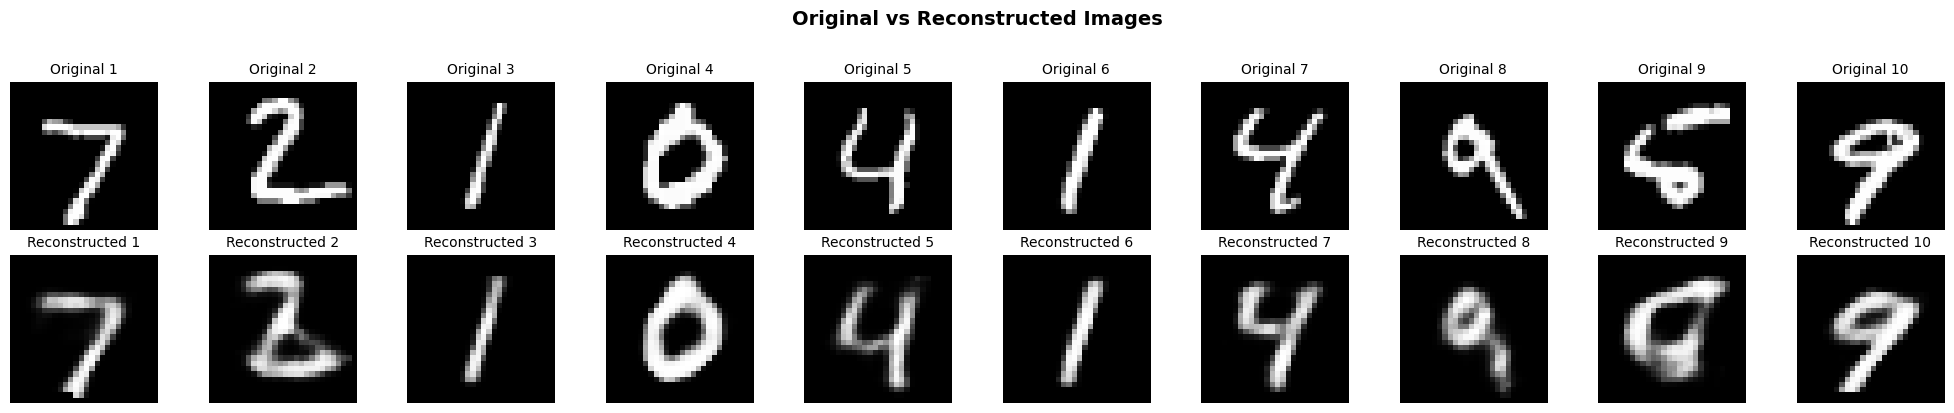

In [8]:
# Visualize original vs reconstructed images
n_images = 10
plt.figure(figsize=(20, 4))

for i in range(n_images):
    # Original images
    ax = plt.subplot(2, n_images, i + 1)
    original_img = x_test_flat[i].reshape(28, 28)
    plt.imshow(original_img, cmap='gray')
    plt.title(f"Original {i+1}", fontsize=10)
    plt.axis('off')
    
    # Reconstructed images
    ax = plt.subplot(2, n_images, i + 1 + n_images)
    reconstructed_img = x_test_pred[i].reshape(28, 28)
    plt.imshow(reconstructed_img, cmap='gray')
    plt.title(f"Reconstructed {i+1}", fontsize=10)
    plt.axis('off')

plt.suptitle("Original vs Reconstructed Images", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

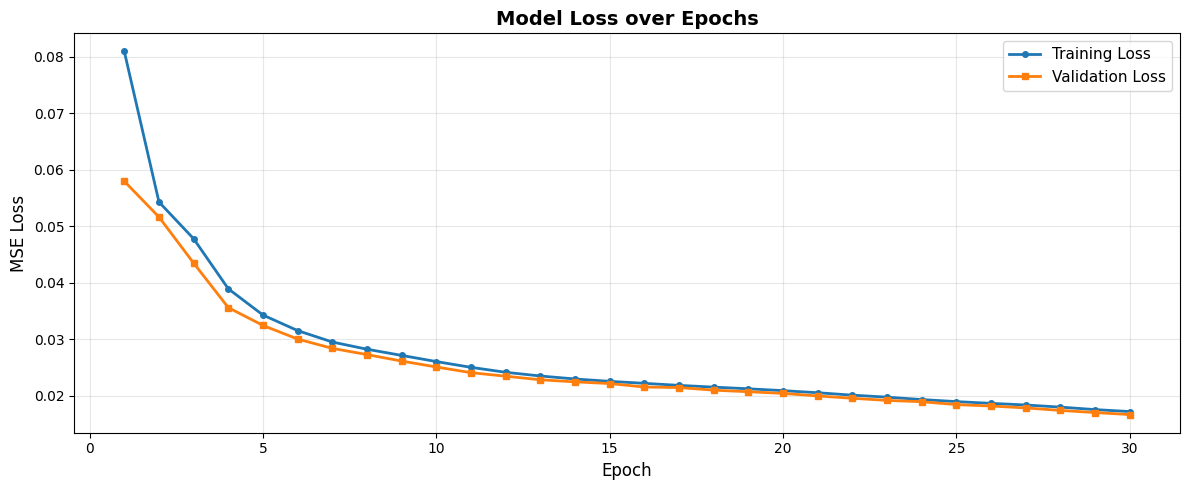

In [9]:
# Plot training history
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

epochs_range = range(1, num_epochs + 1)
ax.plot(epochs_range, train_losses, label='Training Loss', linewidth=2, marker='o', markersize=4)
ax.plot(epochs_range, val_losses, label='Validation Loss', linewidth=2, marker='s', markersize=4)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MSE Loss', fontsize=12)
ax.set_title('Model Loss over Epochs', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

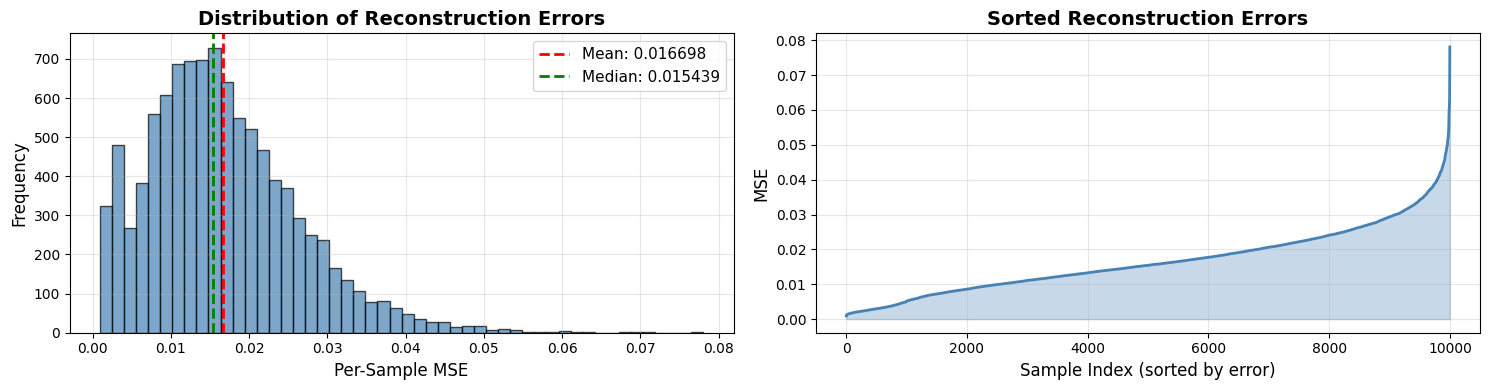

In [10]:
# Visualize reconstruction error distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Histogram of per-sample reconstruction errors
axes[0].hist(per_sample_mse, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(per_sample_mse.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {per_sample_mse.mean():.6f}')
axes[0].axvline(np.median(per_sample_mse), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(per_sample_mse):.6f}')
axes[0].set_xlabel('Per-Sample MSE', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Reconstruction Errors', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Sorted reconstruction errors
sorted_errors = np.sort(per_sample_mse)
axes[1].plot(sorted_errors, linewidth=2, color='steelblue')
axes[1].fill_between(range(len(sorted_errors)), sorted_errors, alpha=0.3, color='steelblue')
axes[1].set_xlabel('Sample Index (sorted by error)', fontsize=12)
axes[1].set_ylabel('MSE', fontsize=12)
axes[1].set_title('Sorted Reconstruction Errors', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

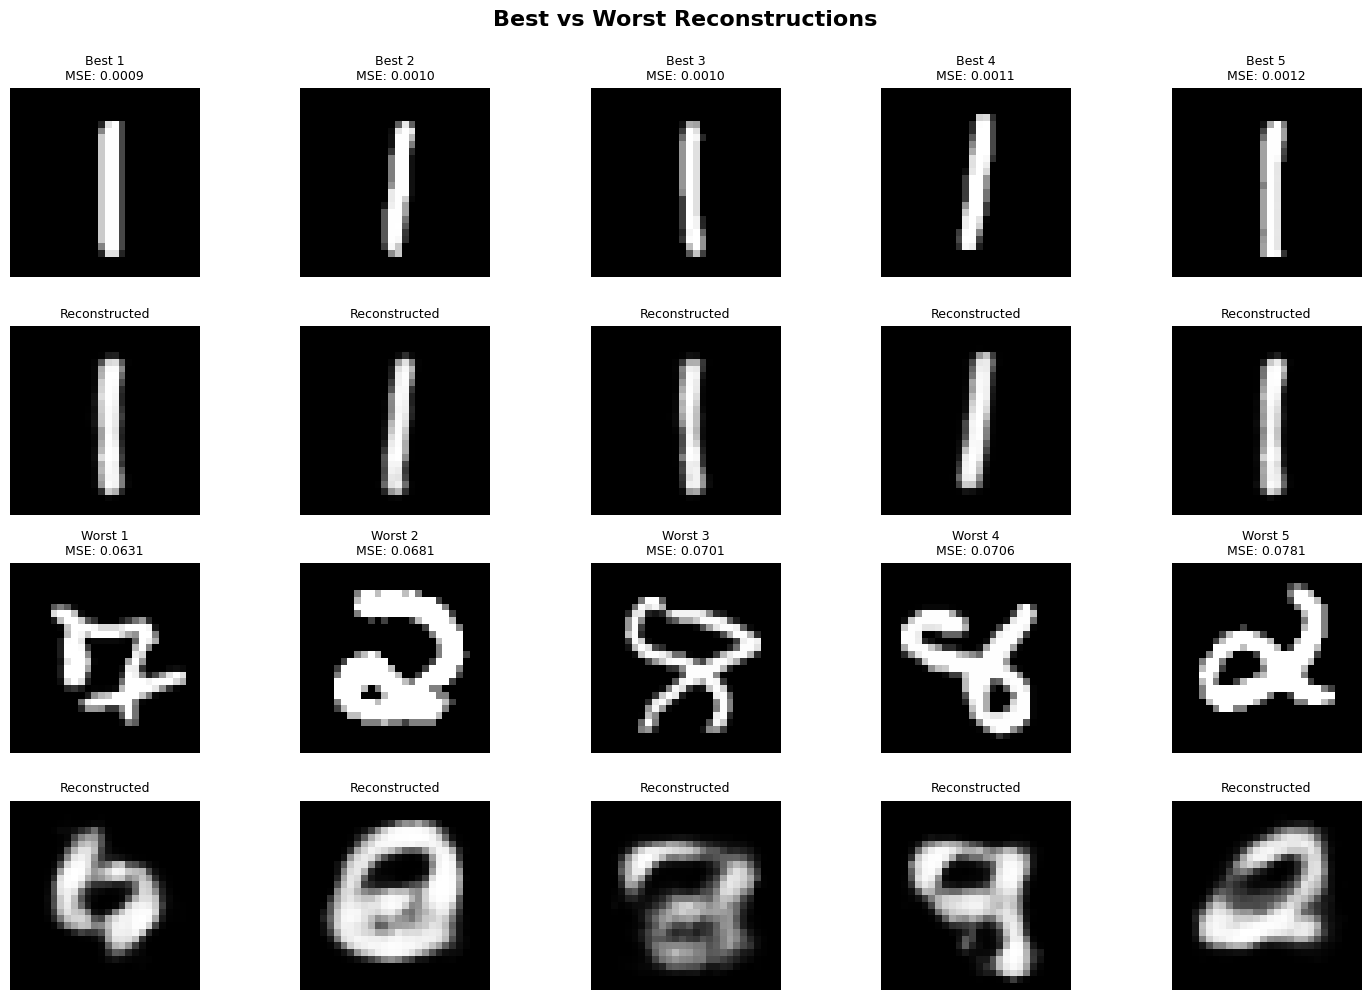

In [11]:
# Visualize best and worst reconstructions
best_indices = np.argsort(per_sample_mse)[:5]  # 5 best
worst_indices = np.argsort(per_sample_mse)[-5:]  # 5 worst

fig, axes = plt.subplots(4, 5, figsize=(15, 10))

# Best reconstructions
for idx, sample_idx in enumerate(best_indices):
    ax = axes[0, idx]
    original = x_test_flat[sample_idx].reshape(28, 28)
    ax.imshow(original, cmap='gray')
    ax.set_title(f"Best {idx+1}\nMSE: {per_sample_mse[sample_idx]:.4f}", fontsize=9)
    ax.axis('off')
    
    ax = axes[1, idx]
    reconstructed = x_test_pred[sample_idx].reshape(28, 28)
    ax.imshow(reconstructed, cmap='gray')
    ax.set_title(f"Reconstructed", fontsize=9)
    ax.axis('off')

# Worst reconstructions
for idx, sample_idx in enumerate(worst_indices):
    ax = axes[2, idx]
    original = x_test_flat[sample_idx].reshape(28, 28)
    ax.imshow(original, cmap='gray')
    ax.set_title(f"Worst {idx+1}\nMSE: {per_sample_mse[sample_idx]:.4f}", fontsize=9)
    ax.axis('off')
    
    ax = axes[3, idx]
    reconstructed = x_test_pred[sample_idx].reshape(28, 28)
    ax.imshow(reconstructed, cmap='gray')
    ax.set_title(f"Reconstructed", fontsize=9)
    ax.axis('off')

fig.suptitle('Best vs Worst Reconstructions', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Basic Autoencoder for Data Reconstruction (PyTorch)

This notebook implements a basic autoencoder neural network using PyTorch to reconstruct input data. We'll train it on the MNIST dataset and evaluate its reconstruction error.